## CNN Baseline

### Setup & Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing necessary libraries
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
IMAGE_SIZE=256
BATCH_SIZE=8
CHANNELS=3
EPOCHS=50

In [ ]:
#Loading Dataset
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Deep Learning/Dataset",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2063 files belonging to 7 classes.


In [ ]:
#Printing the name of the classes of rocks
class_names=dataset.class_names
print(class_names)

['Basalt', 'Coal', 'Granite', 'Limestone', 'Marble', 'Quartzite', 'Sandstone']


In [ ]:
#print length of dataset
len(dataset)

258

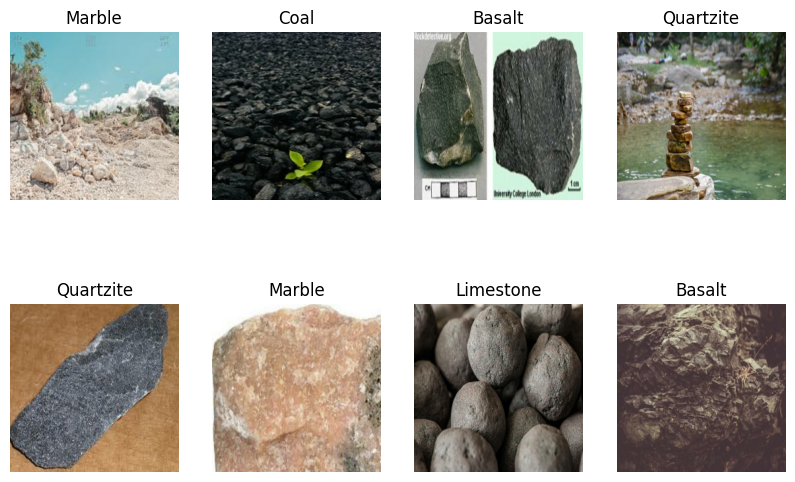

In [ ]:
#Printing first 12 data in first batch
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(8):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])

### Data preparation

In [ ]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    print(val_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)


    return train_ds,val_ds,test_ds

In [ ]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

25


In [ ]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

206
25
27


In [ ]:
train_ds=train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
])

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

### CNN Model

In [ ]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=7
model=models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(n_classes,activation="softmax"),

])
model.build(input_shape=input_shape)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (8, 256, 256, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (8, 256, 256, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (8, 254, 254, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (8, 127, 127, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (8, 125, 125, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (8, 62, 62, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (8, 60, 60, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (8, 30, 30, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (8, 28, 28, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (8, 14, 14, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (8, 12, 12, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (8, 6, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (8, 4, 4, 64)          │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (8, 2, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (8, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (8, 64)                │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 7)                 │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,007 (718.78 KB)

 Trainable params: 184,007 (718.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.2653 - loss: 1.7814 - val_accuracy: 0.4200 - val_loss: 1.5583
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.3406 - loss: 1.6050 - val_accuracy: 0.4350 - val_loss: 1.4432
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3807 - loss: 1.5178 - val_accuracy: 0.3700 - val_loss: 1.5271
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.4260 - loss: 1.4597 - val_accuracy: 0.3600 - val_loss: 1.5444
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.4444 - loss: 1.4508 - val_accuracy: 0.4350 - val_loss: 1.4323
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - accuracy: 0.4444 - loss: 1.4197 - val_accuracy: 0.4550 - val_loss: 1.3849
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.4693 - loss: 1.4053 - val_accuracy: 0.4950 - val_loss: 1.3603
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.4827 - loss: 1.3848 - 

### Evaluation

In [ ]:
scores=model.evaluate(test_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6481 - loss: 1.0072


In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

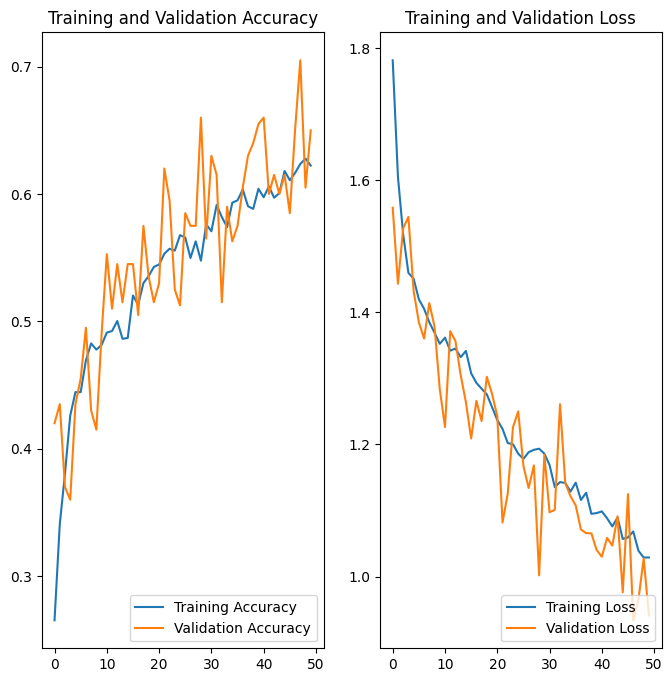

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Training Accuracy")
plt.plot(range(EPOCHS),val_acc,label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label="Training Loss")
plt.plot(range(EPOCHS),val_loss,label="Validation Loss")
plt.legend(loc="lower right")
plt.title('Training and Validation Loss')

## Fine-Tuning with VGG16

### Dependencies

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data loading

In [6]:
import os

data_path = "/content/drive/MyDrive/Deep Learning/Dataset"

print("Data folder exists:", os.path.exists(data_path))

if os.path.exists(data_path):
    classes = sorted([
        folder for folder in os.listdir(data_path)
        if os.path.isdir(os.path.join(data_path, folder))
    ])

    print("\nNumber of class folders:", len(classes))
    print("Class folders:")

    for cls in classes:
        class_path = os.path.join(data_path, cls)
        num_images = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        print(f"{cls}: {num_images} images")

Data folder exists: True

Number of class folders: 7
Class folders:
Basalt: 86 images
Coal: 368 images
Granite: 100 images
Limestone: 338 images
Marble: 385 images
Quartzite: 476 images
Sandstone: 324 images


In [7]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
SEED = 12

dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    labels="inferred",
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nClass names:")
print(dataset.class_names)

print("\nNumber of batches:",
      tf.data.experimental.cardinality(dataset).numpy())

Found 2063 files belonging to 7 classes.

Class names:
['Basalt', 'Coal', 'Granite', 'Limestone', 'Marble', 'Quartzite', 'Sandstone']

Number of batches: 516


In [8]:
images, labels = next(iter(dataset))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels.numpy())
print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

Image shape: (4, 256, 256, 3)
Label shape: (4,)
Labels: [6 3 3 1]
Pixel range: 0.0 to 255.0


### Train/Test Split and preprocessing

In [9]:
from sklearn.model_selection import train_test_split
from PIL import Image

image_paths = []
labels = []

for class_id, class_name in enumerate(classes):
    class_path = os.path.join(data_path, class_name)

    for file in os.listdir(class_path):
        path = os.path.join(class_path, file)

        try:
            with Image.open(path) as img:
                img.verify()

            image_paths.append(path)
            labels.append(class_id)

        except:
            pass

print("Valid images:", len(image_paths))
print("Classes:", classes)

Valid images: 2077
Classes: ['Basalt', 'Coal', 'Granite', 'Limestone', 'Marble', 'Quartzite', 'Sandstone']


In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 1661
Validation: 208
Test: 208


In [11]:
BATCH_SIZE = 4

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (256, 256))
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_ds = train_ds.shuffle(len(train_paths), seed=SEED)
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 416
Validation batches: 52
Test batches: 52


### Class Imbalance analysis

In [12]:
from collections import Counter

print(dict(zip(classes, np.bincount(train_labels))))

{'Basalt': np.int64(69), 'Coal': np.int64(294), 'Granite': np.int64(80), 'Limestone': np.int64(270), 'Marble': np.int64(308), 'Quartzite': np.int64(381), 'Sandstone': np.int64(259)}


In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(classes)),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

for i, cls in enumerate(classes):
    print(cls, round(class_weights[i], 2))

Basalt 3.44
Coal 0.81
Granite 2.97
Limestone 0.88
Marble 0.77
Quartzite 0.62
Sandstone 0.92


### Data Augmentation

In [46]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

### Load pretrained VGG16

In [47]:
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

conv_base.trainable = False

In [48]:
model = keras.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input),
    conv_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(7, activation="softmax")
])

model.build((None, 256, 256, 3))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [49]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_w = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.4437 - loss: 2.1883 - val_accuracy: 0.6106 - val_loss: 1.0844
Epoch 2/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.5738 - loss: 1.2225 - val_accuracy: 0.6538 - val_loss: 0.9562
Epoch 3/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.6328 - loss: 1.0249 - val_accuracy: 0.6538 - val_loss: 0.9348
Epoch 4/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.6526 - loss: 0.9381 - val_accuracy: 0.7019 - val_loss: 0.9073
Epoch 5/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.6905 - loss: 0.8537 - val_accuracy: 0.6827 - val_loss: 0.8940
Epoch 6/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.7164 - loss: 0.7752 - val_accuracy: 0.6779 - val_loss: 0.9207
Epoch 7/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7207 - loss: 0.7806 - val_accuracy: 0.7212 - val_loss: 0.8647
Epoch 8/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.7459 - loss: 0.6910 - 

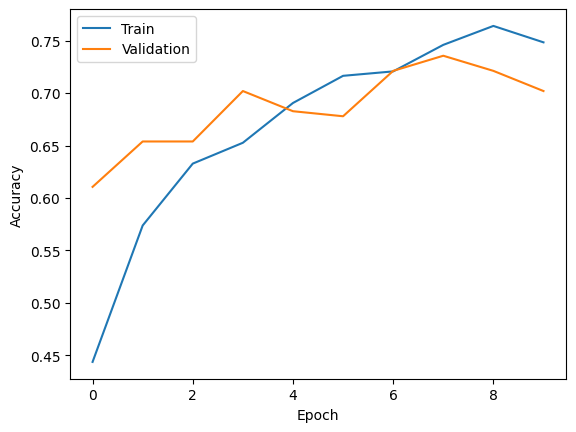

In [51]:
plt.plot(history_w.history["accuracy"], label="Train")
plt.plot(history_w.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Actual Fine-Tuning

In [52]:
for layer in conv_base.layers:
    if layer.name in [
        "block5_conv1",
        "block5_conv2",
        "block5_conv3"
    ]:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
    if "block5" in layer.name:
        print(layer.name, layer.trainable)

block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool False


In [53]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 7,212,551 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [55]:
early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_ft]
)

Epoch 1/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.7790 - loss: 0.5850 - val_accuracy: 0.7212 - val_loss: 0.8715
Epoch 2/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8170 - loss: 0.5288 - val_accuracy: 0.7308 - val_loss: 0.9692
Epoch 3/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.8405 - loss: 0.4443 - val_accuracy: 0.7163 - val_loss: 0.9151
Epoch 4/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8567 - loss: 0.4250 - val_accuracy: 0.7212 - val_loss: 0.8772


### Evaluate

In [56]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7308 - loss: 0.9180
Test accuracy: 0.7307692170143127
Test loss: 0.9179601073265076


In [57]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Test samples:", len(y_true))

Test samples: 208


In [58]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=dataset.class_names
))

              precision    recall  f1-score   support

      Basalt       0.29      0.25      0.27         8
        Coal       0.85      0.95      0.90        37
     Granite       0.42      0.50      0.45        10
   Limestone       0.68      0.68      0.68        34
      Marble       0.68      0.74      0.71        38
   Quartzite       0.74      0.65      0.69        48
   Sandstone       0.90      0.85      0.88        33

    accuracy                           0.73       208
   macro avg       0.65      0.66      0.65       208
weighted avg       0.73      0.73      0.73       208



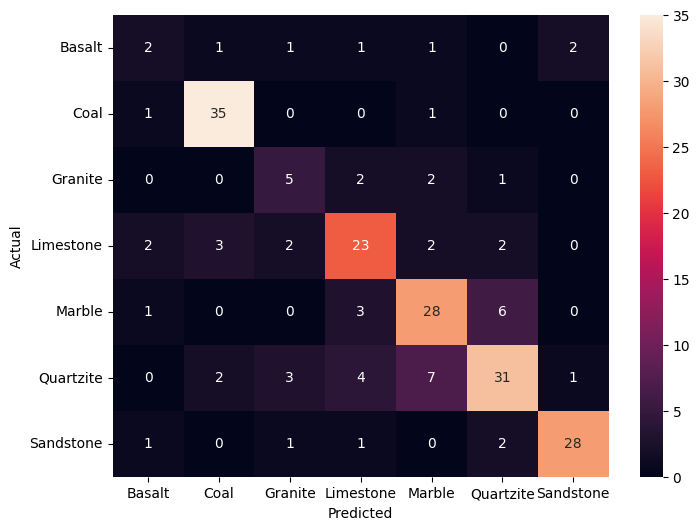

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.class_names,
    yticklabels=dataset.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Built a predictive system

In [60]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = classes[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

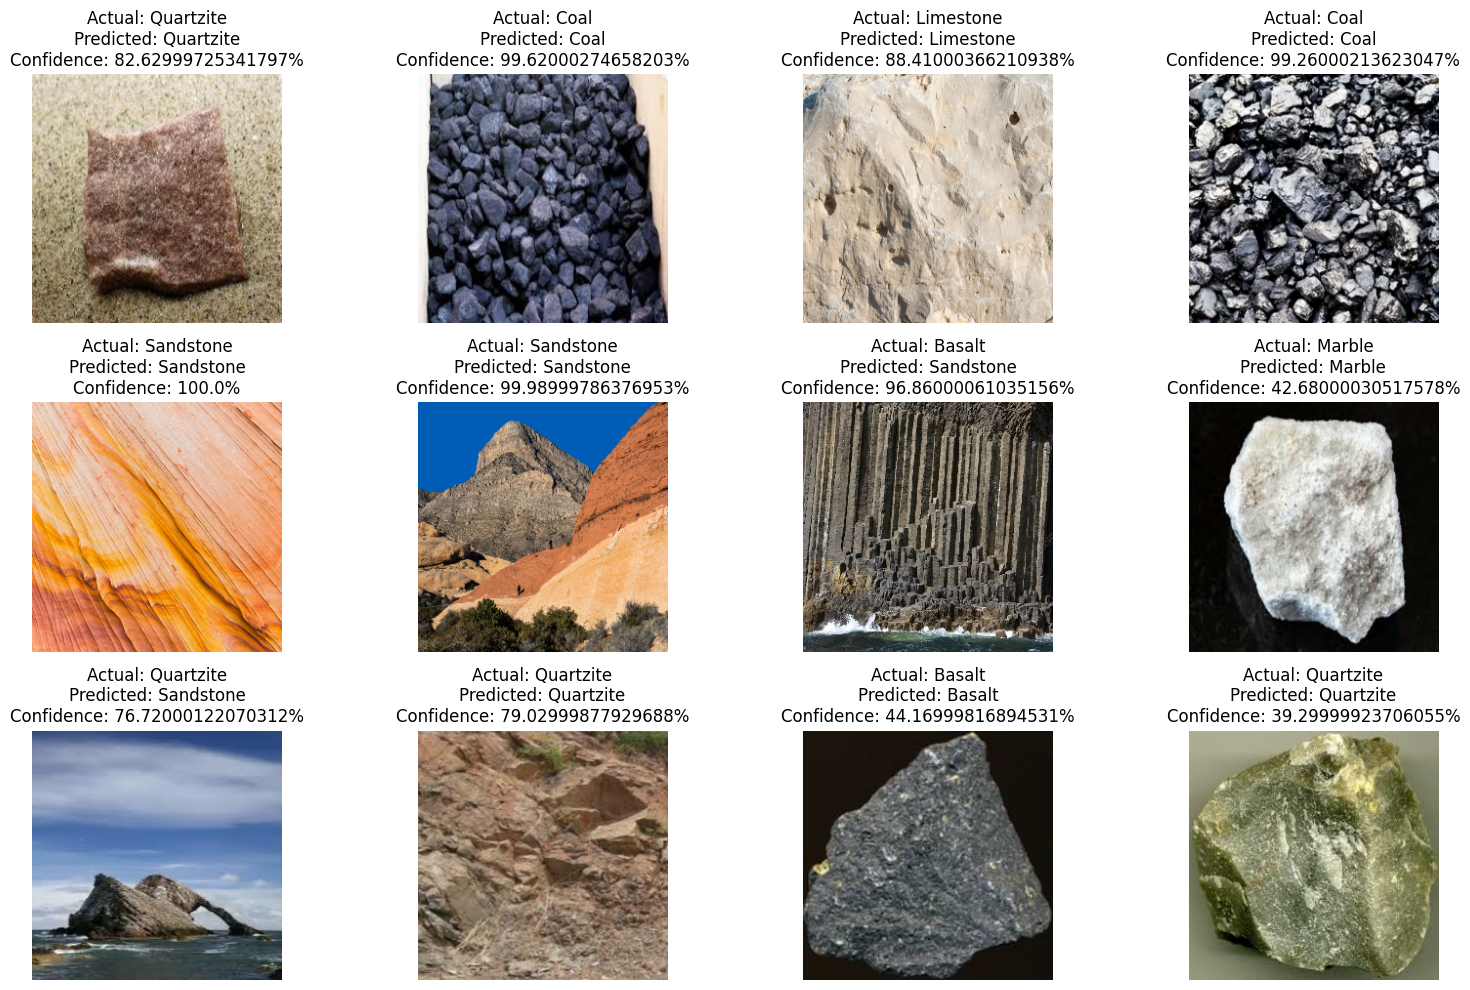

In [61]:
plt.figure(figsize=(16, 10))

count = 0

for images, labels in test_ds.take(3):
    for i in range(len(images)):
        plt.subplot(3, 4, count + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = classes[labels[i].numpy()]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )
        count += 1

plt.tight_layout()

plt.show()

In [70]:
import importlib
import rock_predictor

importlib.reload(rock_predictor)

from rock_predictor import predict_rock

Saving 4.jpg to 4 (1).jpg



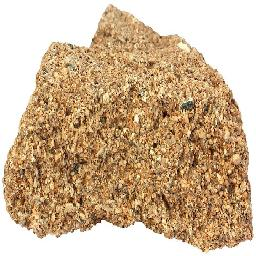

ROCK CLASSIFICATION RESULT
Predicted Rock : Granite
Confidence     : 93.31%
Confidence Gap : 89.22%
Assessment     : HIGH CONFIDENCE

Top 3 Predictions:
1. Granite      93.31%
2. Basalt       4.09%
3. Limestone    2.33%


In [71]:
predict_rock(model, classes)